# Analisis Sentimen Publik terhadap Direktorat Jenderal Pajak

**Sumber data:** postingan publik platform Threads
**Objek sentimen:** DJP sebagai institusi (kebijakan, layanan, pegawai)
**Kelas:** Positif, Negatif, Netral

---

Notebook ini menjalankan seluruh alur: audit kualitas data, analisis deskriptif,
preprocessing, ekstraksi fitur, pemodelan, evaluasi, interpretasi, dan penyimpanan
artefak model yang dipakai aplikasi Streamlit.

**Urutan pengerjaan yang disarankan:** jalankan seluruh sel dari atas ke bawah.
Sel terakhir menyimpan model ke folder `artefak/`, yang dibaca langsung oleh
`app/app.py`.


## 0. Persiapan lingkungan

Kalau `Sastrawi` belum terpasang, jalankan sel di bawah sekali saja. Modul
preprocessing tetap berjalan tanpa Sastrawi, hanya tanpa stemming.


In [1]:
# !pip install pandas scikit-learn matplotlib seaborn Sastrawi joblib streamlit

import sys, os, warnings, json
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'app'))
sys.path.insert(0, os.path.join(os.getcwd(), 'app'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['font.size'] = 9

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('pandas', pd.__version__)
import sklearn; print('scikit-learn', sklearn.__version__)

pandas 3.0.2


scikit-learn 1.8.0


## 1. Latar belakang dan rumusan masalah

**Masalah.** Percakapan publik tentang DJP di media sosial berlangsung terus-menerus
dan volumenya jauh melebihi kapasitas pembacaan manual. Tanpa alat bantu, unit
kehumasan hanya bisa menangkap isu yang sudah viral, yaitu ketika biaya
penanganannya sudah tinggi.

**Tujuan proyek.** Membangun model klasifikasi yang menandai sentimen sebuah
postingan terhadap DJP ke dalam tiga kelas, sehingga pemantauan persepsi publik
bisa dilakukan secara terukur dan berkala.

**Batasan.** Model ini adalah alat penyaring awal, bukan pengganti pembacaan
manusia. Keluarannya dipakai untuk memprioritaskan mana yang perlu dibaca lebih
dulu, bukan untuk mengambil keputusan kebijakan secara langsung.


### 1.1 Kerangka metodologis

Proyek ini diperlakukan sebagai **analisis isi (content analysis)** yang sebagian
tahapannya diotomasi, bukan sekadar tugas klasifikasi teks. Konsekuensinya, mutu
pelabelan diperlakukan sebagai obyek pengukuran tersendiri, bukan sebagai asumsi.

**Komponen menurut Krippendorff (2019).** Alur kerja mengikuti urutan: penentuan
unit, penarikan sampel, perekaman/pengodean, penyederhanaan, penarikan inferensi,
dan pelaporan. Tiga jenis unit dibedakan secara eksplisit di buku kode: unit
sampling, unit rekam, dan unit konteks.

**Prosedur menurut Neuendorf (2017).** Pengodean manusia didahului penyusunan buku
kode, pelatihan pelabel, dan uji keandalan awal; uji keandalan akhir dilakukan pada
subsampel acak terpisah, dan nilai dari uji akhir inilah yang dilaporkan.

**Definisi opini menurut Liu (2015).** Opini dirumuskan sebagai quintuple
(e, a, s, h, t). Proyek ini menetapkan e = DJP sebagai institusi, a = GENERAL,
s = tiga nilai sentimen, h = penulis postingan, t = waktu posting. Klasifikasi
tingkat dokumen berarti menentukan s pada aspek GENERAL.

Penetapan e secara eksplisit adalah inti perbaikan terhadap pelabelan awal. Tanpa
entitas yang ditetapkan, penilaian berayun mengikuti kesan pelabel, dan itulah yang
terbukti terjadi: tujuh kelompok teks identik memperoleh label berbeda.


## 2. Pemuatan data dan audit kualitas

Data dibaca dari workbook relabeling. Notebook otomatis memakai kolom
`LABEL BARU` bila relabeling sudah selesai, dan jatuh ke `Label Lama` bila belum,
disertai peringatan. Hasil dengan label lama hanya boleh dipakai sebagai
pembanding, bukan sebagai hasil akhir.


In [2]:
SUMBER = '../data/Buku_Kode_dan_Pelabelan_Sentimen_DJP.xlsx'
if not os.path.exists(SUMBER):
    SUMBER = 'data/Buku_Kode_dan_Pelabelan_Sentimen_DJP.xlsx'

df = pd.read_excel(SUMBER, sheet_name='Relabeling')
print('dimensi:', df.shape)
df.head(3)

dimensi: (264, 10)


,ID,No Asli,Username,Tanggal,Isi Thread,Label Lama,Konflik Label,LABEL BARU,ASPEK (opsional),Catatan
0,1,1,_vinetta,2026-03-03,Qadarullah semalam terima kabar ini\nSelamat a...,positif,NaN,NaN,NaN,NaN
1,2,2,nrachman77,2026-03-24,Saya punya teman orang pajak. Tiap hari ketika...,negatif,NaN,NaN,NaN,NaN
2,3,3,nafkahnation.dx,2026-04-19,Temen gw kerja di KPP Pratama. Bagian pelayana...,negatif,NaN,NaN,NaN,NaN


In [3]:
KELAS_VALID = ['negatif', 'netral', 'positif']

baru = df['LABEL BARU'].astype(str).str.strip().str.lower()
terisi = baru.isin(KELAS_VALID + ['tidak relevan']).sum()

if terisi >= 0.9 * len(df):
    df['label'] = baru
    SUMBER_LABEL = 'LABEL BARU (hasil relabeling)'
else:
    df['label'] = df['Label Lama'].astype(str).str.strip().str.lower()
    SUMBER_LABEL = 'Label Lama (relabeling BELUM selesai)'
    print('PERINGATAN: relabeling belum selesai (' + str(terisi) + '/' + str(len(df)) + ' terisi).')
    print('Hasil di bawah memakai label lama yang diketahui tidak konsisten.')
    print('Angka ini hanya sah dipakai sebagai baseline pembanding.')

print('Sumber label:', SUMBER_LABEL)

n_relevan = int((df['label'] == 'tidak relevan').sum())
df_model = df[df['label'].isin(KELAS_VALID)].copy()
print('Dibuang (tidak relevan):', n_relevan)
print('Baris untuk pemodelan:', len(df_model))

PERINGATAN: relabeling belum selesai (0/264 terisi).
Hasil di bawah memakai label lama yang diketahui tidak konsisten.
Angka ini hanya sah dipakai sebagai baseline pembanding.
Sumber label: Label Lama (relabeling BELUM selesai)
Dibuang (tidak relevan): 0
Baris untuk pemodelan: 263


### 2.1 Audit kualitas

Empat hal yang diperiksa: kelengkapan kolom, keseimbangan kelas, panjang teks,
dan sisa duplikasi. Duplikat persis sudah dibuang pada tahap pembersihan
sebelumnya (25 baris dari 289), sehingga pemeriksaan di sini bersifat verifikasi.


In [4]:
audit = pd.DataFrame({
    'Kolom': df.columns,
    'Kosong': [df[k].isna().sum() for k in df.columns],
    'Unik': [df[k].nunique() for k in df.columns],
})
display(audit)

print('Duplikat teks tersisa:', df_model['Isi Thread'].str.lower().str.strip().duplicated().sum())
print('Baris tanpa tanggal  :', int((df_model['Tanggal'].isna() | (df_model['Tanggal'].astype(str) == 'nan')).sum()))

,Kolom,Kosong,Unik
0,ID,0,264
1,No Asli,0,264
2,Username,2,222
3,Tanggal,95,93
4,Isi Thread,0,264
5,Label Lama,0,4
6,Konflik Label,257,1
7,LABEL BARU,264,0
8,ASPEK (opsional),264,0
9,Catatan,264,0


Duplikat teks tersisa: 0
Baris tanpa tanggal  : 95


## 2.5 Keandalan pengodean

Bagian ini mengukur seberapa konsisten pelabelan dilakukan, sebelum data dipakai
melatih model. Krippendorff (2019, Bab 12) menganjurkan **Krippendorff's alpha**
alih-alih persentase kesepakatan mentah, karena persentase kesepakatan tidak
mengoreksi kesepakatan yang dapat terjadi secara kebetulan: pada data yang kelasnya
timpang, dua pelabel yang sama-sama condong ke kelas mayoritas bisa mencatat
persentase tinggi tanpa benar-benar sepakat atas kategorinya.

Standar yang dipakai: alpha di atas 0,800 dapat diandalkan; 0,667 sampai 0,800
hanya untuk kesimpulan sementara; di bawah 0,667 belum layak dipakai.

Sel di bawah membaca lembar **Uji Keandalan Awal** dan **Uji Keandalan Akhir**.
Bila lembar masih kosong, sel akan melaporkannya dan melewati perhitungan.


In [5]:
from reliabilitas import krippendorff_alpha, alpha_dengan_selang, matriks_pelabel, tafsir

def uji_keandalan(nama_lembar):
    lembar = pd.read_excel(SUMBER, sheet_name=nama_lembar, skiprows=3)
    # Baris ringkasan di bawah tabel ikut terbaca, jadi disaring lewat ID numerik
    lembar = lembar[pd.to_numeric(lembar['ID'], errors='coerce').notna()]
    A = lembar['PELABEL A'].tolist()
    B = lembar['PELABEL B'].tolist()

    terisi_a = sum(1 for v in A if isinstance(v, str) and v.strip())
    terisi_b = sum(1 for v in B if isinstance(v, str) and v.strip())
    print(nama_lembar)
    print('  unit           :', len(lembar))
    print('  terisi A / B   :', terisi_a, '/', terisi_b)

    if terisi_a < 10 or terisi_b < 10:
        print('  BELUM DAPAT DIHITUNG. Isi kedua kolom pada lembar ini terlebih dahulu.')
        print('  Lihat Bagian 5 buku kode untuk prosedurnya.')
        return None

    hasil = alpha_dengan_selang([A, B])
    print('  alpha          : %.4f' % hasil['alpha'])
    print('  selang 95%%     : %.4f sampai %.4f' % (hasil['batas_bawah_95'], hasil['batas_atas_95']))
    print('  peluang < 0,800: %.3f' % hasil['peluang_di_bawah_0800'])
    print('  ->', tafsir(hasil['alpha']))
    return {'lembar': nama_lembar, 'A': A, 'B': B, **hasil}

hasil_awal = uji_keandalan('Uji Keandalan Awal')
print()
hasil_akhir = uji_keandalan('Uji Keandalan Akhir')

KEANDALAN = hasil_akhir or hasil_awal

Uji Keandalan Awal
  unit           : 40
  terisi A / B   : 0 / 0
  BELUM DAPAT DIHITUNG. Isi kedua kolom pada lembar ini terlebih dahulu.
  Lihat Bagian 5 buku kode untuk prosedurnya.

Uji Keandalan Akhir
  unit           : 50
  terisi A / B   : 0 / 0
  BELUM DAPAT DIHITUNG. Isi kedua kolom pada lembar ini terlebih dahulu.
  Lihat Bagian 5 buku kode untuk prosedurnya.


### 2.5.1 Matriks silang antarpelabel

Neuendorf (2017) menyarankan pemeriksaan matriks Pelabel A terhadap Pelabel B, bukan
hanya angka alpha tunggal. Ketidaksepakatan yang terpusat pada satu pasangan kategori
menandakan definisi kategori yang belum tegas di buku kode, dan itu dapat diperbaiki.
Ketidaksepakatan yang tersebar merata menandakan masalah pada pelatihan pelabel.


In [6]:
if KEANDALAN:
    kelas4 = ['Positif', 'Negatif', 'Netral', 'Tidak Relevan']
    m = matriks_pelabel(KEANDALAN['A'], KEANDALAN['B'], kelas4)
    display(m)

    beda = m.values.sum() - np.trace(m.values)
    print('Total tidak sepakat:', int(beda))
    if beda:
        pasangan = []
        for i, ka in enumerate(kelas4):
            for j, kb in enumerate(kelas4):
                if i != j and m.values[i, j]:
                    pasangan.append((int(m.values[i, j]), ka, kb))
        pasangan.sort(reverse=True)
        print()
        print('Pasangan kategori paling sering tertukar:')
        for jml, ka, kb in pasangan[:3]:
            print('  %-14s vs %-14s : %d kasus' % (ka, kb, jml))
        print()
        print('Perbaiki definisi pasangan teratas di buku kode sebelum melanjutkan.')
else:
    print('Matriks dilewati: uji keandalan belum diisi.')

Matriks dilewati: uji keandalan belum diisi.


## 3. Analisis deskriptif

Bagian ini menjawab butir 5 pada kerangka paparan: gambaran data sebelum dimodelkan.


In [7]:
dist = df_model['label'].value_counts().reindex(KELAS_VALID)
proporsi = (dist / dist.sum() * 100).round(1)
ringkas = pd.DataFrame({'Jumlah': dist, 'Persen': proporsi})
display(ringkas)

rasio = dist.max() / dist.min()
print('Rasio kelas terbesar : terkecil = %.2f : 1' % rasio)
if rasio > 1.5:
    print('Kelas tidak seimbang. Evaluasi memakai F1 macro, bukan akurasi,')
    print('dan model diberi class_weight="balanced".')

,Jumlah,Persen
label,,
negatif,126,47.9
netral,75,28.5
positif,62,23.6


Rasio kelas terbesar : terkecil = 2.03 : 1
Kelas tidak seimbang. Evaluasi memakai F1 macro, bukan akurasi,
dan model diberi class_weight="balanced".


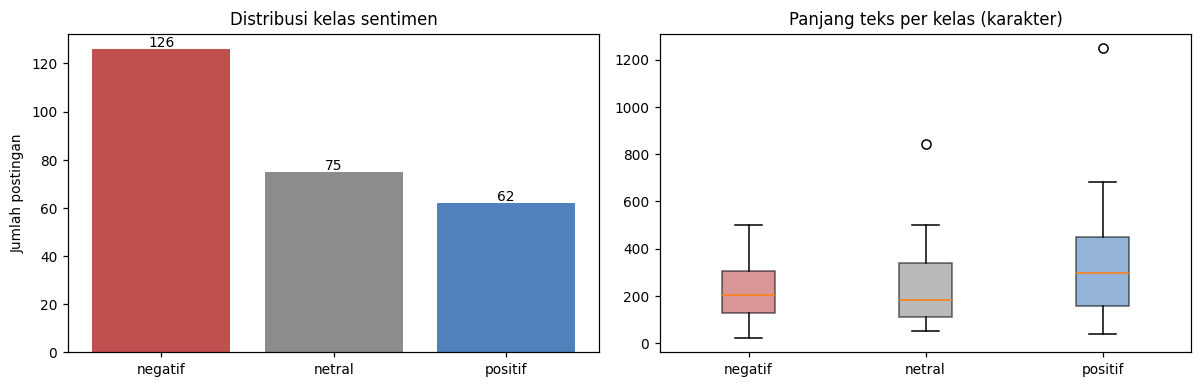

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negatif,126.0,231.7,132.0,22.0,126.8,202.5,306.0,500.0
netral,75.0,237.6,156.0,51.0,111.5,182.0,339.0,842.0
positif,62.0,309.9,198.2,39.0,157.5,298.5,448.5,1248.0


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

warna = {'negatif': '#C0504D', 'netral': '#8C8C8C', 'positif': '#4F81BD'}
ax[0].bar(dist.index, dist.values, color=[warna[k] for k in dist.index])
for i, v in enumerate(dist.values):
    ax[0].text(i, v + 1, str(v), ha='center', fontsize=9)
ax[0].set_title('Distribusi kelas sentimen')
ax[0].set_ylabel('Jumlah postingan')

df_model['panjang'] = df_model['Isi Thread'].str.len()
data_box = [df_model.loc[df_model.label == k, 'panjang'].values for k in KELAS_VALID]
bp = ax[1].boxplot(data_box, labels=KELAS_VALID, patch_artist=True)
for patch, k in zip(bp['boxes'], KELAS_VALID):
    patch.set_facecolor(warna[k]); patch.set_alpha(.6)
ax[1].set_title('Panjang teks per kelas (karakter)')

plt.tight_layout()
os.makedirs('../gambar', exist_ok=True)
plt.savefig('../gambar/eda_distribusi.png', bbox_inches='tight', dpi=150)
plt.show()

display(df_model.groupby('label')['panjang'].describe().round(1))

### 3.1 Kata yang paling sering muncul per kelas

Frekuensi mentah didominasi kata umum, sehingga yang ditampilkan adalah kata
setelah preprocessing. Ini berguna untuk memeriksa apakah kelas benar-benar
terpisah secara kosakata, atau justru bertumpang tindih.


Teks kosong setelah preprocessing: 0


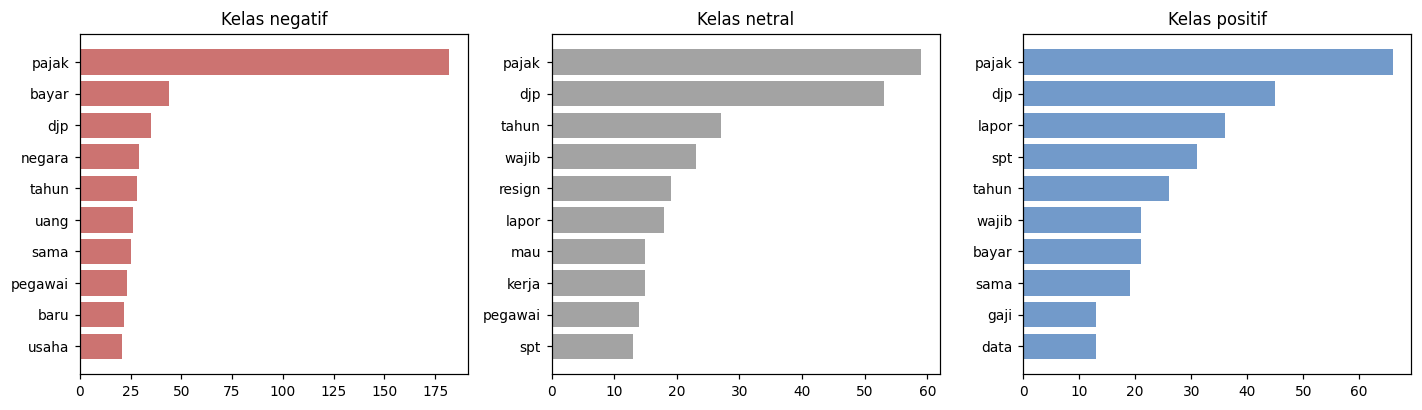

In [9]:
from preprocessing import preprocess_batch, preprocess

df_model['teks_bersih'] = preprocess_batch(df_model['Isi Thread'].tolist())

kosong = (df_model['teks_bersih'].str.strip() == '').sum()
print('Teks kosong setelah preprocessing:', kosong)
df_model = df_model[df_model['teks_bersih'].str.strip() != ''].reset_index(drop=True)

from collections import Counter
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax_, k in zip(axes, KELAS_VALID):
    kata = Counter(' '.join(df_model.loc[df_model.label == k, 'teks_bersih']).split())
    top = kata.most_common(10)[::-1]
    ax_.barh([t[0] for t in top], [t[1] for t in top], color=warna[k], alpha=.8)
    ax_.set_title('Kelas ' + k)
plt.tight_layout()
plt.savefig('../gambar/eda_kata_teratas.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.2 Contoh hasil preprocessing

Perlu diperiksa manual pada beberapa baris. Preprocessing yang terlalu agresif
bisa menghapus justru kata yang membawa sentimen.


In [10]:
for i in range(3):
    print('ASLI  :', df_model['Isi Thread'][i][:180].replace(chr(10), ' '))
    print('BERSIH:', df_model['teks_bersih'][i][:180])
    print('LABEL :', df_model['label'][i])
    print('-' * 90)

ASLI  : Qadarullah semalam terima kabar ini Selamat atas promosinya suamiku sayang. Semoga selalu langkahmu dimudahkan Allah swt.. Semangat untuk keluarga kecil kita yaa Aku selalu sayang 
BERSIH: qadarullah malam terima kabar selamat atas promosi suami sayang moga selalu langkah mudah allah swt semangat keluarga kecil selalu sayang sama mas lama awal meni tahun ldm ketemu m
LABEL : positif
------------------------------------------------------------------------------------------
ASLI  : Saya punya teman orang pajak. Tiap hari ketika kerja selalu was was, kerja ga enak hati dan pikirannya suka ga fokus. Salah satu yang bikin ia tenang jika ibadah tepat waktu, rata2
BERSIH: teman pajak tiap hari kerja selalu was was kerja tidak_enak hati pikir suka tidak_fokus salah satu bikin tenang ibadah tepat rata pegawai pajak rajin ibadah sholat tepat suka sedek
LABEL : negatif
------------------------------------------------------------------------------------------
ASLI  : Temen gw kerja di KPP 

## 4. Teknik preprocessing yang dipakai

Urutan tahapan, seluruhnya ada di `app/preprocessing.py` sehingga notebook dan
aplikasi memakai fungsi yang sama:

1. **Case folding dan pembersihan** — huruf kecil, buang URL, mention, emoji,
   angka, dan tanda baca; rapatkan huruf berulang (`bangettt` menjadi `banget`).
2. **Normalisasi kata tidak baku** — kamus khusus korpus ini, termasuk singkatan
   domain (`wp` menjadi `wajib pajak`, `tukin` menjadi `tunjangan kinerja`).
3. **Penghapusan stopword** — kata negasi sengaja **tidak** dibuang.
4. **Penggabungan negasi** — `tidak bagus` menjadi satu token `tidak_bagus`.
   Tanpa langkah ini, TF-IDF unigram memperlakukan `tidak` dan `bagus` sebagai
   dua fitur terpisah dan negasi hilang.
5. **Stemming** — Sastrawi, dengan pengecualian daftar istilah domain supaya
   `pemeriksaan` dan `pajak` tidak berubah bentuk.


## 5. Ekstraksi fitur dan pemodelan

**Ekstraksi fitur.** TF-IDF dengan unigram dan bigram. Bigram dipertahankan karena
frasa seperti `wajib_pajak` dan `tidak_lapor` membawa makna yang hilang bila
dipecah.

**Kandidat model.** Empat algoritma klasik dibandingkan pada kondisi preprocessing
yang identik, sehingga selisih hasil bisa diatribusikan ke algoritmanya.
Deep learning tidak dipakai pada tahap ini karena ukuran data tidak memadai.

**Validasi.** Stratified 5-fold cross validation. Dengan 264 baris, pembagian
train/test tunggal menghasilkan estimasi yang terlalu bergantung pada
keberuntungan pembagian.

**Metrik utama.** F1 macro. Akurasi menyesatkan pada data tidak seimbang: model
yang selalu menebak kelas mayoritas sudah mendapat akurasi tinggi tanpa belajar
apa pun.


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier

# to_numpy(dtype=object) dipakai supaya array tetap bertipe numpy biasa.
# Pada pandas versi baru, .values dapat menghasilkan tipe Arrow yang belum
# sepenuhnya kompatibel dengan pengindeksan internal scikit-learn.
X = df_model['teks_bersih'].astype(str).to_numpy(dtype=object)
y = df_model['label'].astype(str).to_numpy(dtype=object)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Baseline naif: selalu menebak kelas mayoritas. Model apa pun harus mengalahkan ini.
dummy = cross_val_predict(DummyClassifier(strategy='most_frequent'), X, y, cv=cv)
print('Baseline kelas mayoritas -> akurasi %.3f | F1 macro %.3f'
      % ((dummy == y).mean(), f1_score(y, dummy, average='macro')))

Baseline kelas mayoritas -> akurasi 0.479 | F1 macro 0.216


In [12]:
kandidat = {
    'Naive Bayes': MultinomialNB(alpha=0.5),
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced',
                                              C=5, random_state=RANDOM_STATE),
    'Linear SVM': LinearSVC(class_weight='balanced', C=1.0,
                            random_state=RANDOM_STATE, max_iter=5000),
    'Random Forest': RandomForestClassifier(n_estimators=400, class_weight='balanced',
                                            random_state=RANDOM_STATE, n_jobs=-1),
}

prediksi = {}
baris = []
for nama, clf in kandidat.items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
        ('clf', clf),
    ])
    pred = cross_val_predict(pipe, X, y, cv=cv, n_jobs=-1)
    prediksi[nama] = pred
    baris.append({
        'Model': nama,
        'Akurasi': round((pred == y).mean(), 4),
        'F1 Macro': round(f1_score(y, pred, average='macro'), 4),
        'F1 Weighted': round(f1_score(y, pred, average='weighted'), 4),
    })

perbandingan = pd.DataFrame(baris).sort_values('F1 Macro', ascending=False).reset_index(drop=True)
display(perbandingan)

MODEL_TERBAIK = perbandingan.iloc[0]['Model']
print('Model terbaik:', MODEL_TERBAIK)

,Model,Akurasi,F1 Macro,F1 Weighted
0,Logistic Regression,0.5323,0.4986,0.5296
1,Linear SVM,0.5247,0.4889,0.5196
2,Naive Bayes,0.5513,0.4444,0.4981
3,Random Forest,0.5323,0.4037,0.4667


Model terbaik: Logistic Regression


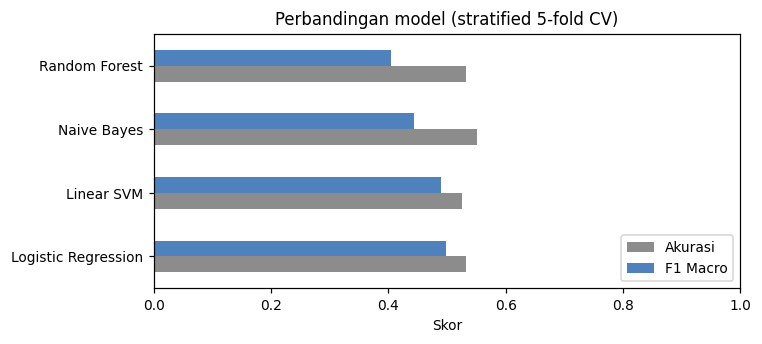

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.2))
p = perbandingan.set_index('Model')[['Akurasi', 'F1 Macro']]
p.plot(kind='barh', ax=ax, color=['#8C8C8C', '#4F81BD'])
ax.set_xlim(0, 1); ax.set_xlabel('Skor'); ax.set_ylabel('')
ax.set_title('Perbandingan model (stratified 5-fold CV)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../gambar/perbandingan_model.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.1 Penyetelan hiperparameter

Yang disetel adalah parameter TF-IDF, bukan hanya parameter classifier. Pada data
kecil, pilihan `min_df` dan rentang n-gram sering berpengaruh lebih besar
daripada pilihan algoritma.


In [14]:
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True)),
    ('clf', kandidat[MODEL_TERBAIK]),
])
grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [1, 2, 3],
    'tfidf__max_df': [0.8, 0.95],
}
gs = GridSearchCV(pipe, grid, cv=cv, scoring='f1_macro', n_jobs=-1)
gs.fit(X, y)

print('Parameter terbaik:')
for k, v in gs.best_params_.items():
    print('  ', k, '=', v)
print('F1 macro (CV): %.4f' % gs.best_score_)

model_final = gs.best_estimator_

Parameter terbaik:
   tfidf__max_df = 0.8
   tfidf__min_df = 1
   tfidf__ngram_range = (1, 2)
F1 macro (CV): 0.5199


## 6. Evaluasi

Angka di bawah dihitung dari `cross_val_predict`, artinya setiap prediksi dibuat
oleh model yang tidak pernah melihat baris tersebut saat pelatihan.


In [15]:
pred_final = cross_val_predict(model_final, X, y, cv=cv, n_jobs=-1)

print('AKURASI  : %.4f' % (pred_final == y).mean())
print('F1 MACRO : %.4f' % f1_score(y, pred_final, average='macro'))
print()
print(classification_report(y, pred_final, digits=3))

AKURASI  : 0.5665
F1 MACRO : 0.5225

              precision    recall  f1-score   support

     negatif      0.633     0.738     0.681       126
      netral      0.470     0.413     0.440        75
     positif      0.500     0.403     0.446        62

    accuracy                          0.567       263
   macro avg      0.534     0.518     0.522       263
weighted avg      0.555     0.567     0.557       263



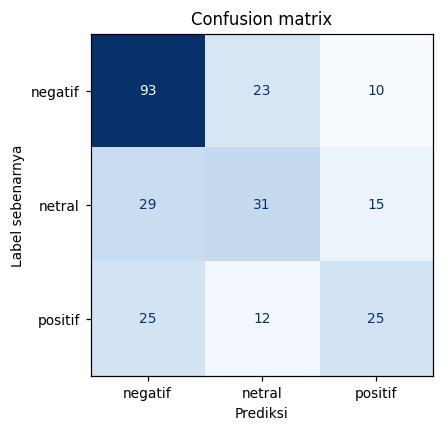

,prediksi negatif,prediksi netral,prediksi positif
aktual negatif,93,23,10
aktual netral,29,31,15
aktual positif,25,12,25


Kelas negatif  paling sering tertukar menjadi netral (23 kasus)
Kelas netral   paling sering tertukar menjadi negatif (29 kasus)
Kelas positif  paling sering tertukar menjadi negatif (25 kasus)


In [16]:
cm = confusion_matrix(y, pred_final, labels=KELAS_VALID)
fig, ax = plt.subplots(figsize=(4.6, 4))
ConfusionMatrixDisplay(cm, display_labels=KELAS_VALID).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion matrix')
ax.set_xlabel('Prediksi'); ax.set_ylabel('Label sebenarnya')
plt.tight_layout()
plt.savefig('../gambar/confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

cm_df = pd.DataFrame(cm, index=['aktual ' + k for k in KELAS_VALID],
                     columns=['prediksi ' + k for k in KELAS_VALID])
display(cm_df)

for i, k in enumerate(KELAS_VALID):
    salah = cm[i].sum() - cm[i, i]
    if salah:
        j = int(np.argmax([cm[i, x] if x != i else -1 for x in range(3)]))
        print('Kelas %-8s paling sering tertukar menjadi %s (%d kasus)' % (k, KELAS_VALID[j], cm[i, j]))

## 7. Interpretasi model

Menampilkan kata dengan bobot terbesar per kelas. Langkah ini wajib: kalau kata
penentu ternyata tidak masuk akal, itu tanda model belajar dari artefak data,
bukan dari sinyal sentimen yang sesungguhnya.


Jumlah fitur: 7464


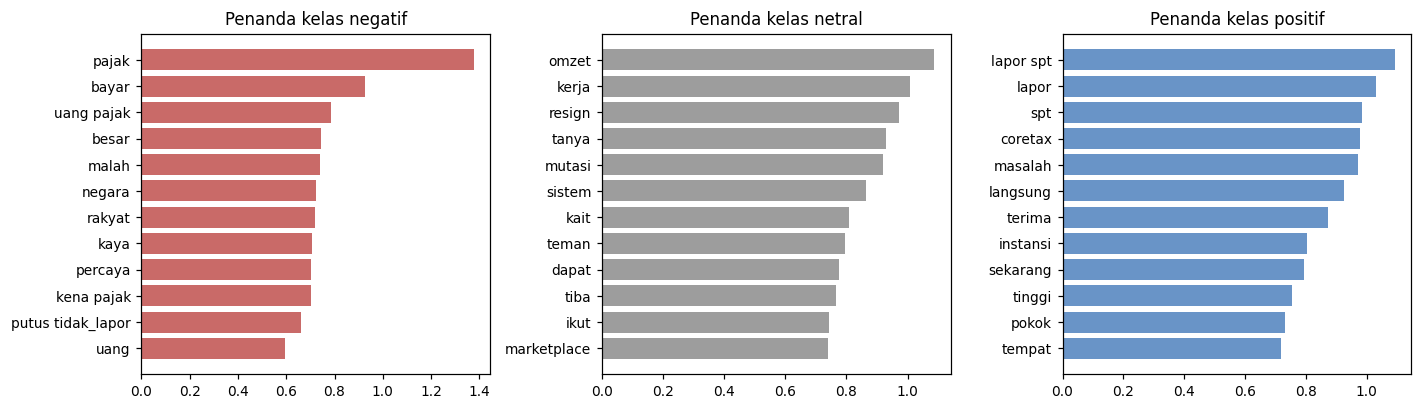

In [17]:
vec = model_final.named_steps['tfidf']
clf = model_final.named_steps['clf']
fitur = np.array(vec.get_feature_names_out())
print('Jumlah fitur:', len(fitur))

if hasattr(clf, 'coef_'):
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
    for ax_, (idx, kelas) in zip(axes, enumerate(clf.classes_)):
        koef = clf.coef_[idx]
        atas = np.argsort(koef)[-12:]
        ax_.barh(fitur[atas], koef[atas], color=warna.get(kelas, '#4F81BD'), alpha=.85)
        ax_.set_title('Penanda kelas ' + kelas)
    plt.tight_layout()
    plt.savefig('../gambar/fitur_penting.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    imp = clf.feature_importances_
    atas = np.argsort(imp)[-20:]
    plt.figure(figsize=(6, 5))
    plt.barh(fitur[atas], imp[atas], color='#4F81BD')
    plt.title('20 fitur paling berpengaruh')
    plt.tight_layout(); plt.show()

## 8. Analisis kesalahan

Membaca kasus yang salah klasifikasi lebih informatif daripada mengejar kenaikan
skor. Pola kesalahan di sini menjadi dasar rekomendasi pada bagian penutup.


In [18]:
salah = df_model[pred_final != y].copy()
salah['prediksi'] = pred_final[pred_final != y]
print('Jumlah salah klasifikasi:', len(salah), 'dari', len(df_model))
print()

for _, r in salah.head(8).iterrows():
    print('[aktual %s -> prediksi %s]' % (r['label'], r['prediksi']))
    print(r['Isi Thread'][:200].replace(chr(10), ' '))
    print('-' * 90)

Jumlah salah klasifikasi: 114 dari 263

[aktual negatif -> prediksi netral]
Saya punya teman orang pajak. Tiap hari ketika kerja selalu was was, kerja ga enak hati dan pikirannya suka ga fokus. Salah satu yang bikin ia tenang jika ibadah tepat waktu, rata2 pegawai pajak itu r
------------------------------------------------------------------------------------------
[aktual negatif -> prediksi netral]
Temen gw kerja di KPP Pratama. Bagian pelayanan. Bukan pemeriksa. Bukan konsultan pajak. Tiap minggu dia liat org dateng, bawa map berisi sertifikat rumah warisan orang tua. Dateng buat urus pajak bal
------------------------------------------------------------------------------------------
[aktual netral -> prediksi positif]
Hari ini di DJP ada pelantikan atas promosi/mutasi pejabat eselon IV. Saya lihat daftarnya, ada beberapa AR yang dipromosikan dengan lokasi penempatan yang relatif jauh, misalnya dari Jakarta ke Atamb
-------------------------------------------------------------------

In [19]:
pola = (salah.groupby(['label', 'prediksi']).size()
        .reset_index(name='jumlah').sort_values('jumlah', ascending=False))
display(pola)

print('Rata-rata panjang teks:')
print('  benar :', round(df_model.loc[pred_final == y, 'panjang'].mean(), 1), 'karakter')
print('  salah :', round(salah['panjang'].mean(), 1), 'karakter')

,label,prediksi,jumlah
2,netral,negatif,29
4,positif,negatif,25
0,negatif,netral,23
3,netral,positif,15
5,positif,netral,12
1,negatif,positif,10


Rata-rata panjang teks:
  benar : 251.0 karakter
  salah : 253.0 karakter


## 9. Penyimpanan artefak

Model dilatih ulang pada seluruh data dengan parameter terbaik, lalu disimpan.
File inilah yang dibaca aplikasi Streamlit.


In [20]:
import joblib
os.makedirs('../artefak', exist_ok=True)

model_final.fit(X, y)
joblib.dump(model_final, '../artefak/model_sentimen.joblib')

metadata = {
    'sumber_label': SUMBER_LABEL,
    'keandalan_alpha': (float(KEANDALAN['alpha']) if KEANDALAN else None),
    'keandalan_lembar': (KEANDALAN['lembar'] if KEANDALAN else None),
    'jumlah_data': int(len(df_model)),
    'distribusi_kelas': {k: int(v) for k, v in dist.items()},
    'model': MODEL_TERBAIK,
    'parameter': {k: str(v) for k, v in gs.best_params_.items()},
    'f1_macro_cv': float(round(f1_score(y, pred_final, average='macro'), 4)),
    'akurasi_cv': float(round((pred_final == y).mean(), 4)),
    'jumlah_fitur': int(len(fitur)),
    'kelas': list(KELAS_VALID),
}
with open('../artefak/metadata_model.json', 'w') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

df_model[['ID', 'Username', 'Isi Thread', 'teks_bersih', 'label']].assign(
    prediksi_cv=pred_final).to_csv('../artefak/hasil_prediksi.csv', index=False)

print('Tersimpan:')
print('  artefak/model_sentimen.joblib')
print('  artefak/metadata_model.json')
print('  artefak/hasil_prediksi.csv')
print()
print(json.dumps(metadata, indent=2, ensure_ascii=False))

Tersimpan:
  artefak/model_sentimen.joblib
  artefak/metadata_model.json
  artefak/hasil_prediksi.csv

{
  "sumber_label": "Label Lama (relabeling BELUM selesai)",
  "keandalan_alpha": null,
  "keandalan_lembar": null,
  "jumlah_data": 263,
  "distribusi_kelas": {
    "negatif": 126,
    "netral": 75,
    "positif": 62
  },
  "model": "Logistic Regression",
  "parameter": {
    "tfidf__max_df": "0.8",
    "tfidf__min_df": "1",
    "tfidf__ngram_range": "(1, 2)"
  },
  "f1_macro_cv": 0.5225,
  "akurasi_cv": 0.5665,
  "jumlah_fitur": 7464,
  "kelas": [
    "negatif",
    "netral",
    "positif"
  ]
}


## 10. Uji coba prediksi

Pemeriksaan cepat pada kalimat yang ditulis manual, untuk memastikan model
berperilaku wajar sebelum dibungkus ke aplikasi.


In [21]:
uji = [
    'Pelayanan di KPP sekarang jauh lebih cepat, petugasnya juga membantu',
    'Pajak makin mencekik, tapi hasilnya dikorupsi terus',
    'Batas akhir pelaporan SPT Tahunan orang pribadi adalah 31 Maret',
    'Kasihan pegawai pajak, dimutasi jauh dari keluarga tapi tetap dihujat',
]
bersih = [preprocess(t) for t in uji]
hasil = model_final.predict(bersih)

for t, h in zip(uji, hasil):
    print('%-9s | %s' % (h.upper(), t))

NEGATIF   | Pelayanan di KPP sekarang jauh lebih cepat, petugasnya juga membantu
NEGATIF   | Pajak makin mencekik, tapi hasilnya dikorupsi terus
POSITIF   | Batas akhir pelaporan SPT Tahunan orang pribadi adalah 31 Maret
NEGATIF   | Kasihan pegawai pajak, dimutasi jauh dari keluarga tapi tetap dihujat


## 11. Keterbatasan dan rencana pengembangan

**Keterbatasan yang harus disampaikan apa adanya.**

1. **Ukuran data.** 264 unit unik. Ini di bawah kebutuhan wajar untuk klasifikasi
   tiga kelas pada teks media sosial yang bervariasi. Konsekuensinya, skor validasi
   silang punya rentang ketidakpastian yang lebar, dan model belum layak dipakai
   untuk keputusan operasional.
2. **Asumsi tingkat dokumen.** Liu (2015, Asumsi 3.1) menyatakan klasifikasi
   tingkat dokumen mengandaikan satu dokumen memuat opini atas satu entitas dari
   satu pemegang opini. Liu secara khusus mencatat asumsi ini berlaku baik untuk
   ulasan produk, tetapi sering tidak berlaku untuk postingan forum dan blog. Data
   ini berasal dari media sosial, sehingga sebagian unit memang menilai lebih dari
   satu entitas. Aturan M2 di buku kode menanganinya dengan memaksa keputusan,
   bukan menghilangkan masalahnya. Analisis berbasis aspek adalah jawaban yang
   sebenarnya.
3. **Penarikan sampel.** Data diambil dari thread yang ramai, bukan secara acak
   dari kerangka sampel yang jelas. Krippendorff (2019, Bab 6) menempatkan
   penarikan sampel sebagai komponen tersendiri justru karena kekeliruan di sini
   tidak dapat diperbaiki pada tahap analisis. Distribusi kelas pada data ini
   menggambarkan komposisi dataset, bukan komposisi opini publik.
4. **Jumlah pelabel.** Bila uji keandalan dikerjakan satu orang dalam dua waktu,
   yang terukur adalah konsistensi internal pelabel, bukan kesepakatan antarpelabel.
   Ukuran ini tidak menangkap bias sistematis yang mungkin dimiliki pelabel tunggal.
5. **Sarkasme.** Liu (2015) mencatat sarkasme jarang muncul pada ulasan produk
   tetapi sering muncul pada percakapan bertema politik. Domain perpajakan dekat
   dengan yang kedua. Model berbasis bobot kata praktis tidak dapat menangkapnya.
6. **Unit rekam sama dengan unit sampling.** Krippendorff (2019, Bab 5) mencatat
   unit sampling sering terlalu kaya untuk dideskripsikan secara andal, sehingga
   unit rekam yang lebih kecil biasanya lebih mudah disepakati. Proyek ini memilih
   satu postingan sebagai satu unit demi kesederhanaan, dan menanggung risiko
   ketidaksepakatan yang lebih tinggi pada postingan panjang.

**Rencana pengembangan berikutnya.**

1. Menyelesaikan uji keandalan akhir dan melaporkan alpha beserta selang
   kepercayaannya bersama hasil model.
2. Menambah data hingga sekitar 1.500–2.000 unit melalui penarikan sampel acak dari
   rentang waktu yang lebih lebar, dengan kerangka sampel yang dinyatakan.
3. Menambah pelabel kedua yang independen, sehingga yang terukur benar-benar
   kesepakatan antarpelabel.
4. Menguji IndoBERT hasil fine-tuning sebagai pembanding. Model pralatih relevan di
   sini justru karena data latih terbatas.
5. Mengembangkan ke analisis sentimen berbasis aspek sesuai kerangka Liu, dengan
   memakai kolom Aspek yang sudah disediakan di lembar pengodean.
6. Menyiapkan mekanisme umpan balik pada aplikasi, sehingga koreksi pengguna
   terkumpul menjadi tambahan data latih.
